In [13]:
import torch
from torch import nn

In [14]:
from d2l import torch as d2l

num_inputs, num_hiddens, num_outputs = 784, 256, 10  # 784 = 28*28

batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)

In [15]:
# requires_grad=True 不应放在 torch.randn 里：
# randn(..., requires_grad=True) * 0.01 会产生非叶子节点，
# nn.Parameter 包裹后梯度无法正常回传。
# 正确做法：先做数值运算（普通 tensor），再交给 nn.Parameter 标记为叶子节点。
W1 = nn.Parameter(torch.randn(num_inputs, num_hiddens) * 0.01)
b1 = nn.Parameter(torch.zeros(num_hiddens))
W2 = nn.Parameter(torch.randn(num_hiddens, num_outputs) * 0.01)
b2 = nn.Parameter(torch.zeros(num_outputs))

params = [W1, b1, W2, b2]

In [16]:
# 激活函数
def relu(X):
    a = torch.zeros_like(X)
    return torch.max(X, a)

In [17]:
# 模型
def net(X):
    X = X.reshape((-1, num_inputs))
    H = relu(X@W1 + b1)
    return (H@W2 + b2)

epoch  1  loss 1.0437  train acc 0.648  test acc 0.745
epoch  2  loss 0.5983  train acc 0.791  test acc 0.798
epoch  3  loss 0.5176  train acc 0.821  test acc 0.783
epoch  4  loss 0.4826  train acc 0.831  test acc 0.826
epoch  5  loss 0.4521  train acc 0.842  test acc 0.793
epoch  6  loss 0.4343  train acc 0.849  test acc 0.828
epoch  7  loss 0.4195  train acc 0.853  test acc 0.841
epoch  8  loss 0.4056  train acc 0.858  test acc 0.845
epoch  9  loss 0.3935  train acc 0.862  test acc 0.847
epoch 10  loss 0.3834  train acc 0.865  test acc 0.852


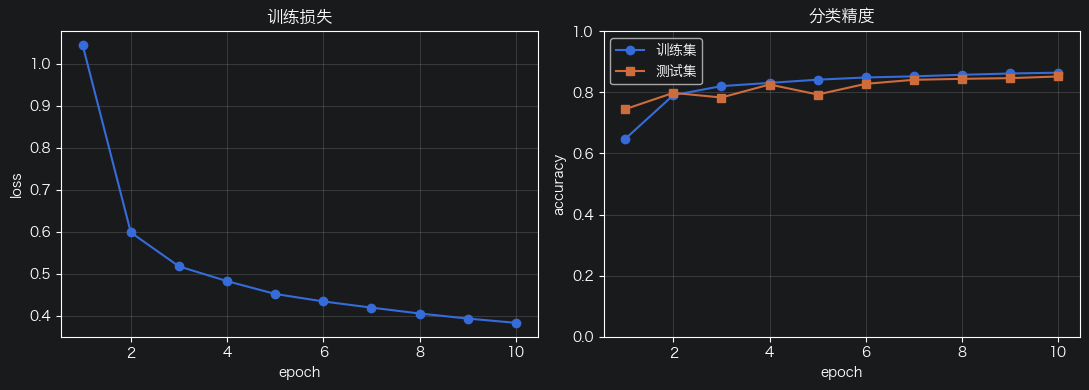

In [18]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont('/System/Library/Fonts/Hiragino Sans GB.ttc')
plt.rcParams['font.family'] = 'Hiragino Sans GB'
plt.rcParams['axes.unicode_minus'] = False

loss = nn.CrossEntropyLoss()  # 默认 reduction='mean'，与 torch.optim.SGD 配合正确
num_epochs, lr = 10, 0.1
updater = torch.optim.SGD(params, lr=lr)

def evaluate_accuracy(net, data_iter):
    correct, total = 0, 0
    with torch.no_grad():
        for X, y in data_iter:
            correct += (net(X).argmax(dim=1) == y).sum().item()
            total += y.numel()
    return correct / total

train_losses, train_accs, test_accs = [], [], []

for epoch in range(num_epochs):
    total_loss, total_correct, total_n = 0.0, 0, 0
    for X, y in train_iter:
        updater.zero_grad()
        y_hat = net(X)
        l = loss(y_hat, y)   # mean loss，梯度量级正常
        l.backward()
        updater.step()
        total_loss    += l.item() * y.numel()
        total_correct += (y_hat.argmax(dim=1) == y).sum().item()
        total_n       += y.numel()
    train_loss = total_loss / total_n
    train_acc  = total_correct / total_n
    test_acc   = evaluate_accuracy(net, test_iter)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    print(f'epoch {epoch+1:2d}  loss {train_loss:.4f}  '
          f'train acc {train_acc:.3f}  test acc {test_acc:.3f}')

epochs = range(1, num_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(epochs, train_losses, marker='o')
axes[0].set_title('训练损失')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, train_accs, marker='o', label='训练集')
axes[1].plot(epochs, test_accs,  marker='s', label='测试集')
axes[1].set_title('分类精度')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('accuracy')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()